In [18]:
!pip install timm scikit-learn

import os
import torch
import torch.nn as nn
import torch.optim as optim
import timm
import numpy as np
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, Subset
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score
from sklearn.preprocessing import label_binarize
from torch.cuda.amp import GradScaler, autocast

In [19]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [20]:
data_dir = "/content/drive/MyDrive/mtech/Training"

transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
])

dataset = datasets.ImageFolder(data_dir, transform=transform)
targets = np.array(dataset.targets)

num_classes = len(dataset.classes)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Classes:", dataset.classes)
print("Total images:", len(dataset))

Classes: ['grade0', 'grade1', 'grade2', 'grade3']
Total images: 2549


In [21]:
def train_one_epoch(model, loader, optimizer, criterion, scaler):
    model.train()
    running_loss = 0

    for images, labels in loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        with autocast():
            outputs = model(images)
            loss = criterion(outputs, labels)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        running_loss += loss.item()

    return running_loss / len(loader)

In [22]:
def evaluate(model, loader):
    model.eval()
    all_preds = []
    all_labels = []
    all_probs = []

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            outputs = model(images)

            probs = torch.softmax(outputs, dim=1)
            preds = torch.argmax(probs, dim=1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.numpy())
            all_probs.extend(probs.cpu().numpy())

    acc = accuracy_score(all_labels, all_preds)
    f1 = f1_score(all_labels, all_preds, average='macro')

    labels_bin = label_binarize(all_labels, classes=list(range(num_classes)))
    roc_auc = roc_auc_score(labels_bin, np.array(all_probs), average='macro')

    return acc, f1, roc_auc

In [23]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

fold_acc = []
fold_f1 = []
fold_auc = []

for fold, (train_idx, val_idx) in enumerate(skf.split(np.zeros(len(targets)), targets)):

    print(f"\n========== Fold {fold+1} ==========")

    train_subset = Subset(dataset, train_idx)
    val_subset   = Subset(dataset, val_idx)

    train_loader = DataLoader(train_subset, batch_size=8, shuffle=True)
    val_loader   = DataLoader(val_subset, batch_size=8, shuffle=False)

    # Reinitialize model each fold
    model = timm.create_model(
        "vit_base_patch16_224",
        pretrained=True,
        num_classes=num_classes
    ).to(device)

    optimizer = optim.AdamW(model.parameters(), lr=1e-5)
    criterion = nn.CrossEntropyLoss()
    scaler = GradScaler()

    epochs = 5   # increase to 10–15 for final experiments

    for epoch in range(epochs):
        loss = train_one_epoch(model, train_loader, optimizer, criterion, scaler)

    acc, f1, auc = evaluate(model, val_loader)

    print("Fold Accuracy:", acc)
    print("Fold F1:", f1)
    print("Fold ROC-AUC:", auc)

    fold_acc.append(acc)
    fold_f1.append(f1)
    fold_auc.append(auc)

    torch.cuda.empty_cache()


========== Fold 1 ==========


model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

/tmp/ipython-input-1328/2536455883.py:26: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler()
/tmp/ipython-input-1328/1072162238.py:11: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Fold Accuracy: 0.9764705882352941
Fold F1: 0.9770510948905109
Fold ROC-AUC: 0.9992042429585807

========== Fold 2 ==========


/tmp/ipython-input-1328/2536455883.py:26: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler()
/tmp/ipython-input-1328/1072162238.py:11: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


...

Fold Accuracy: 0.9823529411764705
Fold F1: 0.9826099540238441
Fold ROC-AUC: 0.9991678487098663

========== Fold 4 ==========


/tmp/ipython-input-1328/2536455883.py:26: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler()
/tmp/ipython-input-1328/1072162238.py:11: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Fold Accuracy: 0.9882352941176471
Fold F1: 0.9886027956806875
Fold ROC-AUC: 0.9997937175319761

========== Fold 5 ==========


/tmp/ipython-input-1328/2536455883.py:26: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler()
/tmp/ipython-input-1328/1072162238.py:11: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Fold Accuracy: 0.962671905697446
Fold F1: 0.9635502434007901
Fold ROC-AUC: 0.9982099149919693


In [24]:
print("\n========== Final 5-Fold Results ==========")

print("Mean Accuracy:", np.mean(fold_acc))
print("Std Accuracy:", np.std(fold_acc))

print("Mean F1:", np.mean(fold_f1))
print("Std F1:", np.std(fold_f1))

print("Mean ROC-AUC:", np.mean(fold_auc))
print("Std ROC-AUC:", np.std(fold_auc))


========== Final 5-Fold Results ==========
Mean Accuracy: 0.9780245772179205
Std Accuracy: 0.008564091453415692
Mean F1: 0.9785404553209218
Std F1: 0.008369564059159739
Mean ROC-AUC: 0.99918059285634
Std ROC-AUC: 0.0005364743104721214


In [25]:
print("\n========== Final 5-Fold Results ==========")

print("Mean Accuracy:", np.mean(fold_acc))
print("Std Accuracy:", np.std(fold_acc))

print("Mean F1:", np.mean(fold_f1))
print("Std F1:", np.std(fold_f1))

print("Mean ROC-AUC:", np.mean(fold_auc))
print("Std ROC-AUC:", np.std(fold_auc))


========== Final 5-Fold Results ==========
Mean Accuracy: 0.9780245772179205
Std Accuracy: 0.008564091453415692
Mean F1: 0.9785404553209218
Std F1: 0.008369564059159739
Mean ROC-AUC: 0.99918059285634
Std ROC-AUC: 0.0005364743104721214


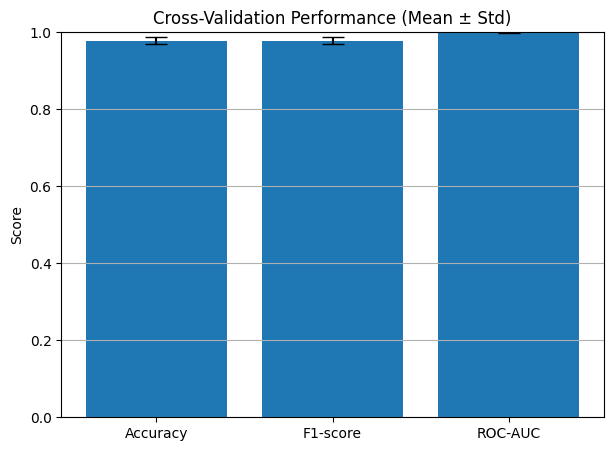

In [26]:
metrics_mean = [
    np.mean(fold_acc),
    np.mean(fold_f1),
    np.mean(fold_auc)
]

metrics_std = [
    np.std(fold_acc),
    np.std(fold_f1),
    np.std(fold_auc)
]

metric_names = ["Accuracy", "F1-score", "ROC-AUC"]

plt.figure(figsize=(7,5))
plt.bar(metric_names, metrics_mean, yerr=metrics_std, capsize=8)

plt.ylabel("Score")
plt.title("Cross-Validation Performance (Mean ± Std)")
plt.ylim(0,1)
plt.grid(axis='y')
plt.show()

In [27]:
fold_losses = []

In [28]:
epoch_losses = []

for epoch in range(epochs):
    loss = train_one_epoch(model, train_loader, optimizer, criterion, scaler)
    epoch_losses.append(loss)

fold_losses.append(epoch_losses)

/tmp/ipython-input-1328/1072162238.py:11: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


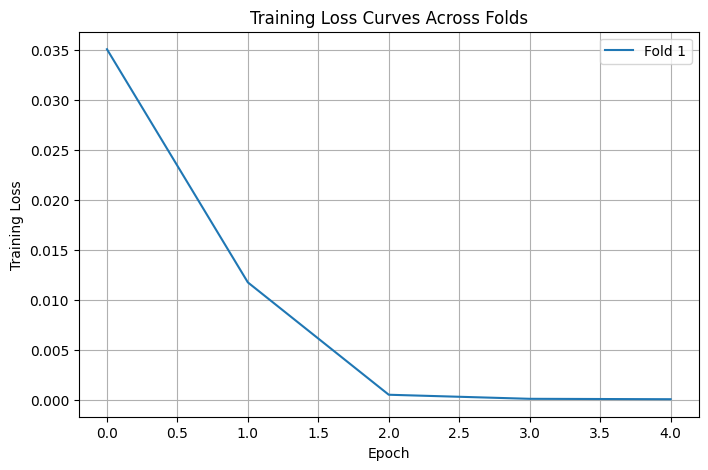

In [29]:
plt.figure(figsize=(8,5))

for i, losses in enumerate(fold_losses):
    plt.plot(losses, label=f"Fold {i+1}")

plt.xlabel("Epoch")
plt.ylabel("Training Loss")
plt.title("Training Loss Curves Across Folds")
plt.legend()
plt.grid()
plt.show()

In [30]:
all_preds_cv = []
all_labels_cv = []

In [31]:
model.eval()
with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(device)
        outputs = model(images)
        preds = torch.argmax(outputs, dim=1)

        all_preds_cv.extend(preds.cpu().numpy())
        all_labels_cv.extend(labels.numpy())

In [32]:
model.eval()
with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(device)
        outputs = model(images)
        preds = torch.argmax(outputs, dim=1)

        all_preds_cv.extend(preds.cpu().numpy())
        all_labels_cv.extend(labels.numpy())

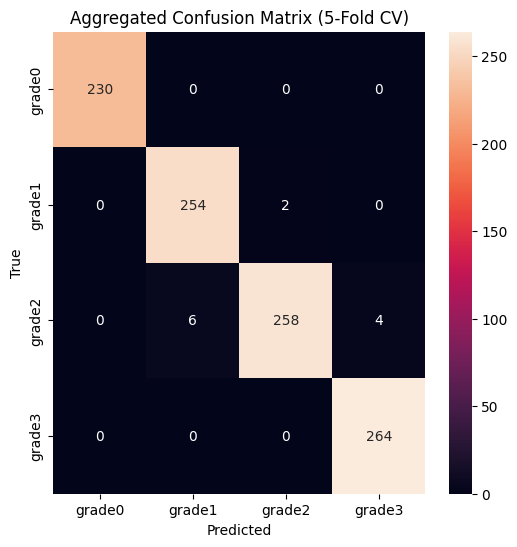

In [33]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(all_labels_cv, all_preds_cv)

plt.figure(figsize=(6,6))
sns.heatmap(cm, annot=True, fmt="d",
            xticklabels=dataset.classes,
            yticklabels=dataset.classes)

plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Aggregated Confusion Matrix (5-Fold CV)")
plt.show()

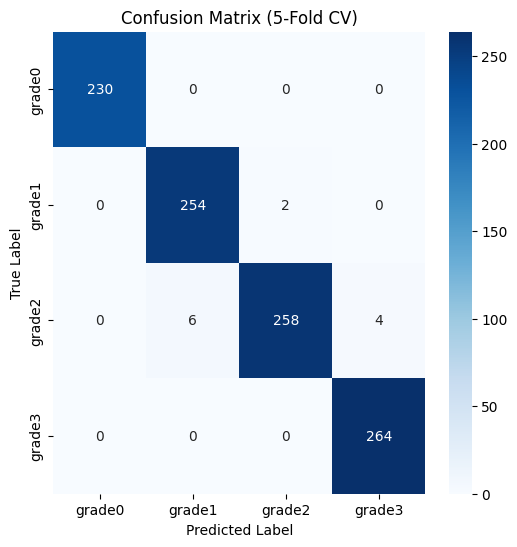

In [34]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(all_labels_cv, all_preds_cv)

plt.figure(figsize=(6,6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",   # 🔵 Blue color map
    xticklabels=dataset.classes,
    yticklabels=dataset.classes
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix (5-Fold CV)")
plt.show()

In [35]:
import torch
import numpy as np

model.eval()

features_list = []
labels_list = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)

        # Extract transformer features
        feats = model.forward_features(images)

        # CLS token (for ViT)
        feats = feats[:, 0]

        features_list.append(feats.cpu())
        labels_list.extend(labels.numpy())

features = torch.cat(features_list).numpy()
labels_np = np.array(labels_list)

print("Feature shape:", features.shape)

Feature shape: (280, 768)


In [38]:
from sklearn.decomposition import PCA

pca = PCA(n_components=50)
features_pca = pca.fit_transform(features)

tsne_results = TSNE(
    n_components=2,
    perplexity=30,
    random_state=42
).fit_transform(features_pca)

In [39]:
from sklearn.manifold import TSNE

tsne = TSNE(
    n_components=2,
    perplexity=30,
    learning_rate=200,
    random_state=42,
    n_iter=1000
)

tsne_results = tsne.fit_transform(features)

/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


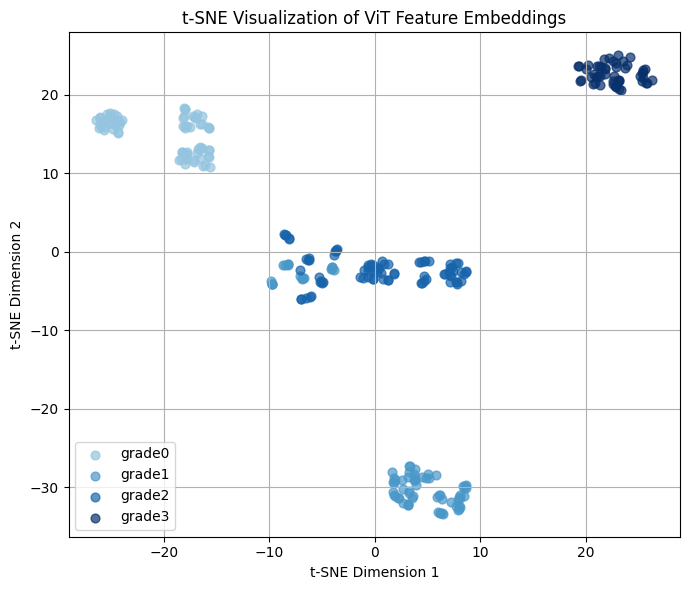

In [40]:
import matplotlib.pyplot as plt

class_names = dataset.classes
n_classes = len(class_names)

plt.figure(figsize=(7,6))

colors = plt.cm.Blues(np.linspace(0.4, 1, n_classes))

for i, class_name in enumerate(class_names):
    idx = labels_np == i
    plt.scatter(
        tsne_results[idx, 0],
        tsne_results[idx, 1],
        label=class_name,
        alpha=0.7,
        s=40,
        color=colors[i]
    )

plt.title("t-SNE Visualization of ViT Feature Embeddings")
plt.xlabel("t-SNE Dimension 1")
plt.ylabel("t-SNE Dimension 2")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()